In [4]:
# Menampilkan file yang diunggah
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import pickle
import io

In [5]:
df = pd.read_csv("Data Historis INDF.csv", delimiter=";")
# Drop unwanted unnamed columns if present
df = df[['Tanggal', 'Terakhir']]
# Show dataframe (verifikasi bahwa kolom Unnamed dihapus)
df

,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [6]:
# Menampilkan data
print("Historis Saham INDF:")
print(f"\nShape data: {df.shape}")
df

Historis Saham INDF:

Shape data: (2415, 2)


,Tanggal,Terakhir
0,23/10/15,6.225
1,26/10/15,6.225
2,27/10/15,6.200
3,28/10/15,6.075
4,29/10/15,5.650
...,...,...
2410,16/10/25,7.075
2411,17/10/25,7.125
2412,20/10/25,7.250
2413,21/10/25,7.275


In [7]:
# Normalize and parse date column (handle different possible column names)
date_col = None
for c in ['Tanggal', 'tanggal', 'Date', 'date']:
    if c in df.columns:
        date_col = c
        break
if date_col is None:
    raise KeyError('No date column found. Expected one of: Tanggal, tanggal, Date, date')
# Robust parsing: try common formats first, then fallback to generic parser
date_series = df[date_col].astype(str).str.strip()
formats = ['%d/%m/%Y', '%Y-%m-%d', '%d-%m-%Y', '%d %b %Y', '%d %B %Y']
final_parsed = pd.Series([pd.NaT] * len(date_series))
for fmt in formats:
    parsed = pd.to_datetime(date_series, format=fmt, dayfirst=True, errors='coerce')
    final_parsed = final_parsed.combine_first(parsed)
if final_parsed.isna().any():
    remaining_idx = final_parsed.isna()
    final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')
df[date_col] = final_parsed
# Rename to consistent column name 'Tanggal'
if date_col != 'Tanggal':
    df = df.rename(columns={date_col: 'Tanggal'})
# Ensure price column is named 'Terakhir' (handle possible variants)
price_col = None
for c in ['Terakhir', 'terakhir', 'Close', 'close']:
    if c in df.columns:
        price_col = c
        break
if price_col is None:
    raise KeyError('No price column found. Expected one of: Terakhir, terakhir, Close, close')
if price_col != 'Terakhir':
    df = df.rename(columns={price_col: 'Terakhir'})
# Sort by the normalized date column
df = df.sort_values('Tanggal')

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_2665/3236093865.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  final_parsed.loc[remaining_idx] = pd.to_datetime(date_series[remaining_idx], dayfirst=True, errors='coerce')


In [8]:
df = df.sort_values('Tanggal')
data = df.set_index('Tanggal')
data

,Terakhir
Tanggal,
2015-10-23,6.225
2015-10-26,6.225
2015-10-27,6.200
2015-10-28,6.075
2015-10-29,5.650
...,...
2025-10-16,7.075
2025-10-17,7.125
2025-10-20,7.250


In [9]:
# Deskripsi data yang digunakan
print("Deskripsi Data:")
print(data.describe())

Deskripsi Data:
          Terakhir
count  2415.000000
mean      7.023333
std       0.792933
min       4.875000
25%       6.400000
50%       6.950000
75%       7.650000
max       9.150000


In [10]:
# Cek missing values
print("Missing Values:")
print(data.isnull().sum())

Missing Values:
Terakhir    0
dtype: int64


In [11]:
# Cek tanggal duplikat
data = data.groupby('Tanggal').mean().reset_index()

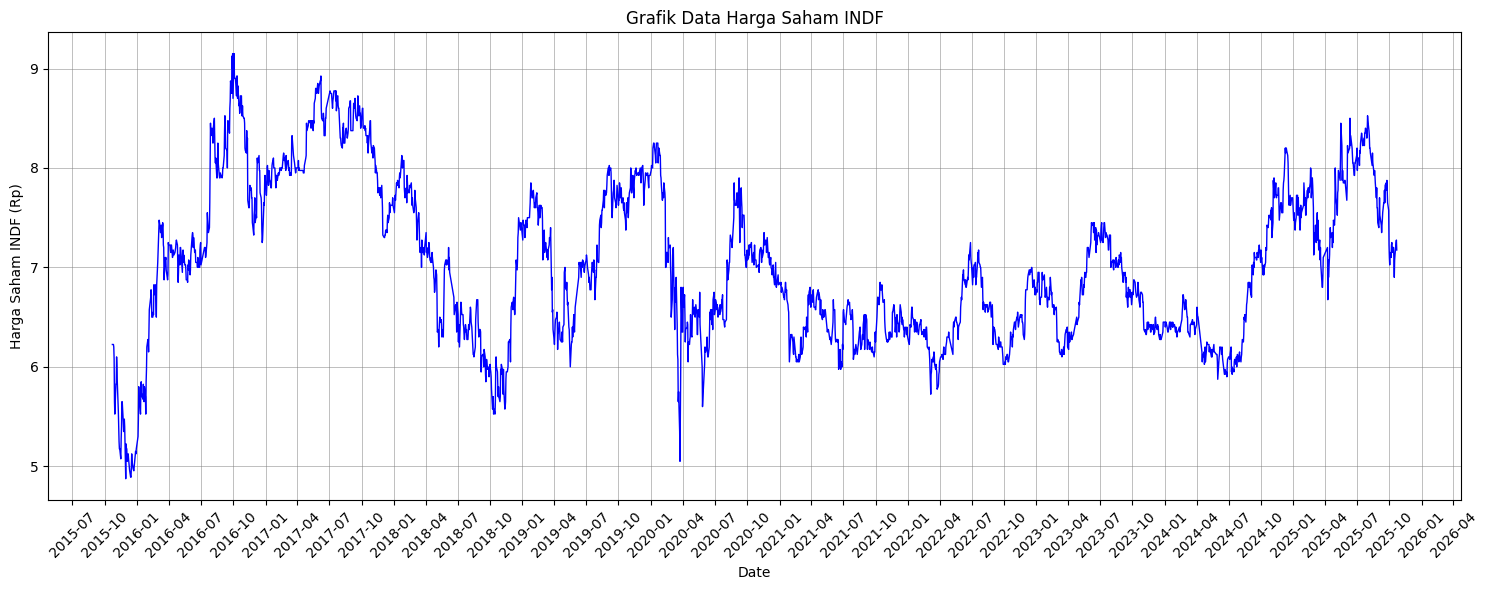

In [12]:
"""#Grafik Data"""

# Membuat plot data
plt.figure(figsize=(15,6))
plt.plot(data['Tanggal'], data['Terakhir'], color='blue', linewidth=1)

# Menambahkan judul dan label sumbu
plt.title('Grafik Data Harga Saham INDF')
plt.xlabel('Date')
plt.ylabel('Harga Saham INDF (Rp)')

# Atur sumbu x agar mudah dibaca
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Menampilkan tanggal setiap 3 bulan
plt.xticks(rotation=45)
plt.tight_layout()

# Menambahkan grid
plt.grid(True, linestyle='-', linewidth=0.5, color='gray', alpha=0.7)

# Menampilkan plot
plt.show()

Outliers:
 Empty DataFrame
Columns: [Tanggal, Terakhir]
Index: []
Tidak ada outlier pada data.


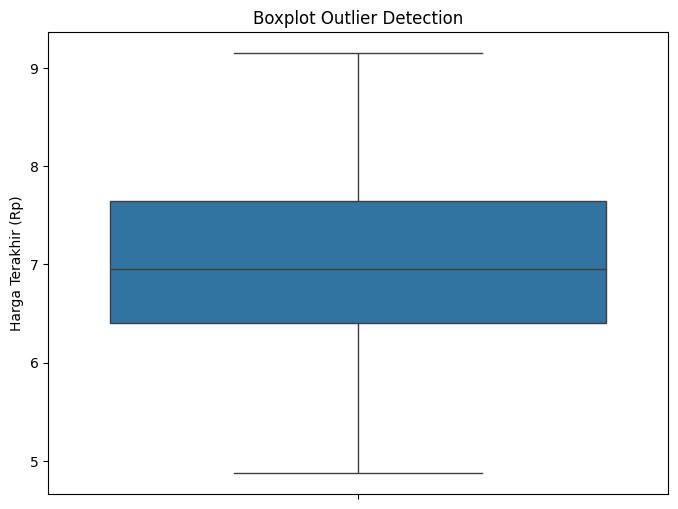

In [ ]:
# """#Pengecekan Data

# ##Pengecekan Outlier
# """
# # Import seaborn, install if missing
# import importlib, subprocess, sys
# try:
#     import seaborn as sns
# except ModuleNotFoundError:
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn'])
#     import seaborn as sns
# import matplotlib.pyplot as plt

# # Cek Outlier
# Q1 = data['Terakhir'].quantile(0.25)
# Q3 = data['Terakhir'].quantile(0.75)
# IQR = Q3 - Q1

# # Menentukan batas bawah dan atas
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# # Deteksi outlier
# outliers = data[(data['Terakhir'] < lower_bound) | (data['Terakhir'] > upper_bound)]
# print("Outliers:\n", outliers)

# # Menilai apakah ada outlier atau tidak
# if outliers.empty:
#     print("Tidak ada outlier pada data.")
# else:
#     print(f"Terdapat {len(outliers)} outlier(s) pada data.")

# # Visualisasi boxplot
# plt.figure(figsize=(8, 6))
# sns.boxplot(data['Terakhir'])
# plt.title("Boxplot Outlier Detection")
# plt.ylabel("Harga Terakhir (Rp)")
# plt.show()

In [14]:
!pip install keras-tcn


🔥 SPLIT 0.6-0.2-0.2
Train: (1441, 12, 1), Val: (480, 12, 1), Test: (482, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE Val: 1.61%

➡️ Kombinasi 2
MAPE Val: 2.69%

➡️ Kombinasi 3
MAPE Val: 1.29%

➡️ Kombinasi 4
MAPE Val: 1.83%

➡️ Kombinasi 5
MAPE Val: 1.56%

➡️ Kombinasi 6
MAPE Val: 2.03%

➡️ Kombinasi 7
MAPE Val: 1.30%

➡️ Kombinasi 8
MAPE Val: 1.58%

➡️ Kombinasi 9
MAPE Val: 1.25%

➡️ Kombinasi 10
MAPE Val: 1.58%

➡️ Kombinasi 11
MAPE Val: 1.39%

➡️ Kombinasi 12
MAPE Val: 1.46%

➡️ Kombinasi 13
MAPE Val: 1.37%

➡️ Kombinasi 14
MAPE Val: 1.45%

➡️ Kombinasi 15
MAPE Val: 1.37%

➡️ Kombinasi 16
MAPE Val: 1.33%

🏆 BEST PARAMS: (64, 2, (1, 2, 4), 32, 0.1, 8, 0.0001)
BEST MAPE VAL: 1.25%


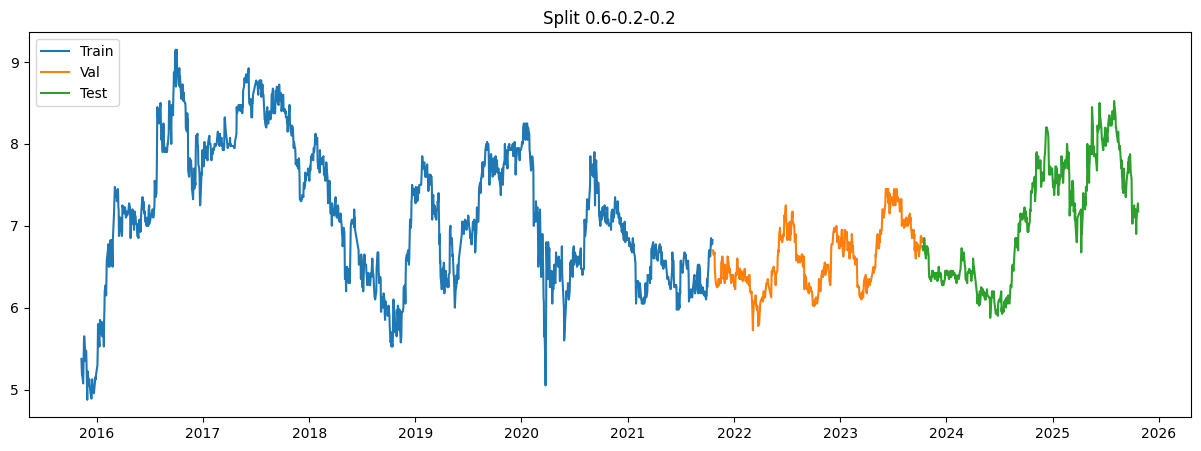


🔥 SPLIT 0.7-0.15-0.15
Train: (1682, 12, 1), Val: (360, 12, 1), Test: (361, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE Val: 1.35%

➡️ Kombinasi 2
MAPE Val: 1.87%

➡️ Kombinasi 3
MAPE Val: 1.15%

➡️ Kombinasi 4
MAPE Val: 1.35%

➡️ Kombinasi 5
MAPE Val: 1.12%

➡️ Kombinasi 6
MAPE Val: 1.42%

➡️ Kombinasi 7
MAPE Val: 1.81%

➡️ Kombinasi 8
MAPE Val: 1.36%

➡️ Kombinasi 9
MAPE Val: 1.17%

➡️ Kombinasi 10
MAPE Val: 1.20%

➡️ Kombinasi 11
MAPE Val: 1.01%

➡️ Kombinasi 12
MAPE Val: 2.11%

➡️ Kombinasi 13
MAPE Val: 1.77%

➡️ Kombinasi 14
MAPE Val: 1.28%

➡️ Kombinasi 15
MAPE Val: 1.20%

➡️ Kombinasi 16
MAPE Val: 1.23%

🏆 BEST PARAMS: (64, 2, (1, 2, 4), 64, 0.1, 8, 0.0001)
BEST MAPE VAL: 1.01%


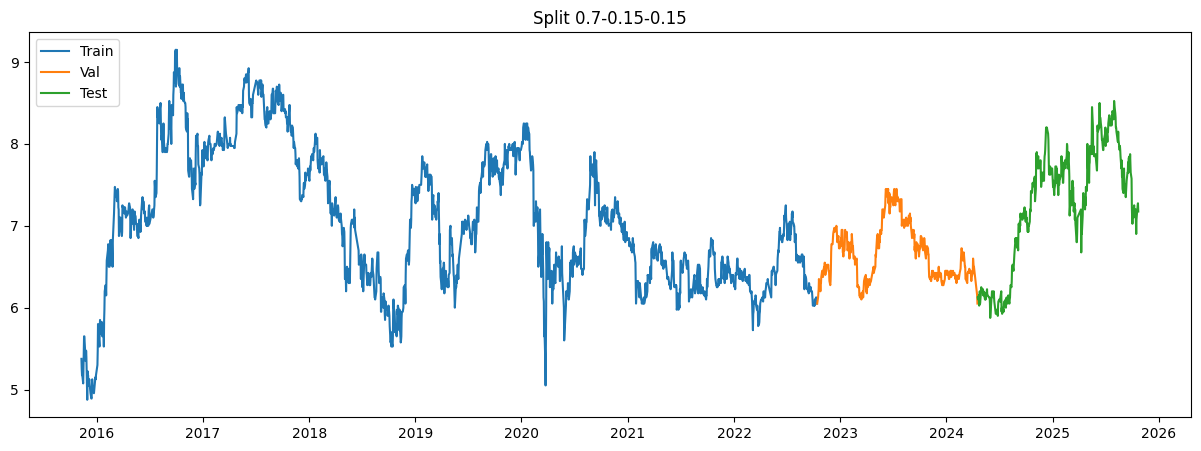


🔥 SPLIT 0.8-0.1-0.1
Train: (1922, 12, 1), Val: (240, 12, 1), Test: (241, 12, 1)
Total kombinasi: 16

➡️ Kombinasi 1
MAPE Val: 1.33%

➡️ Kombinasi 2
MAPE Val: 1.67%

➡️ Kombinasi 3
MAPE Val: 1.05%

➡️ Kombinasi 4
MAPE Val: 1.62%

➡️ Kombinasi 5
MAPE Val: 1.18%

➡️ Kombinasi 6
MAPE Val: 1.92%

➡️ Kombinasi 7
MAPE Val: 1.46%

➡️ Kombinasi 8
MAPE Val: 1.31%

➡️ Kombinasi 9
MAPE Val: 1.08%

➡️ Kombinasi 10
MAPE Val: 1.70%

➡️ Kombinasi 11
MAPE Val: 1.07%

➡️ Kombinasi 12
MAPE Val: 1.06%

➡️ Kombinasi 13
MAPE Val: 1.08%

➡️ Kombinasi 14
MAPE Val: 1.13%

➡️ Kombinasi 15
MAPE Val: 1.32%

➡️ Kombinasi 16
MAPE Val: 1.42%

🏆 BEST PARAMS: (32, 2, (1, 2, 4), 64, 0.1, 8, 0.0001)
BEST MAPE VAL: 1.05%


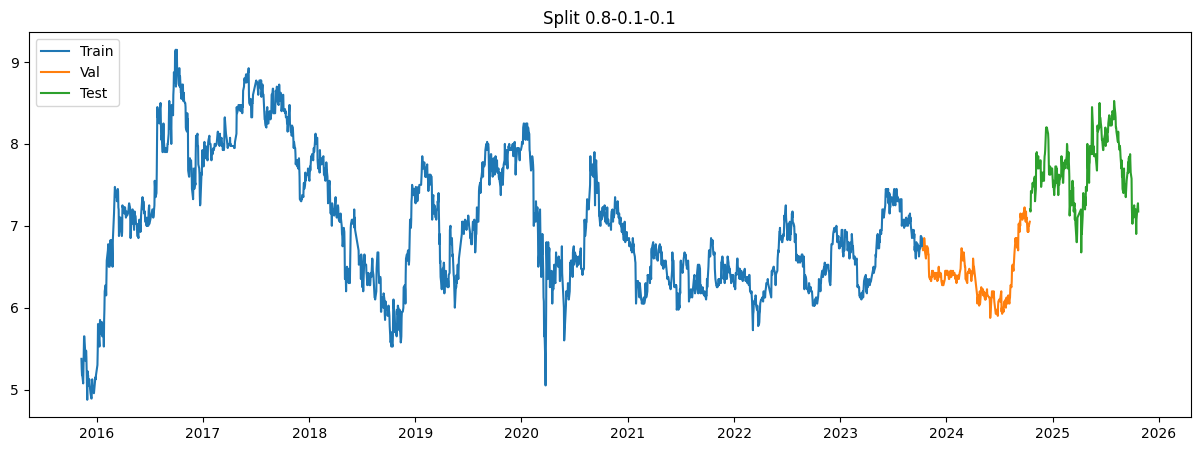


📊 PERBANDINGAN SPLIT:


""


In [15]:
# ===============================
# 1. PREPROCESSING
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Bidirectional, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input

from tcn import TCN
import itertools

tf.random.set_seed(1234)

# ===============================
# 2. SCALING DATA
# ===============================
scaler = MinMaxScaler(feature_range=(0,1))
scaledDataMat = scaler.fit_transform(data[['Terakhir']])

# ===============================
# 3. SEQUENCE DATA
# ===============================
sequence_length = 12

X, y = [], []
for i in range(len(scaledDataMat) - sequence_length):
    X.append(scaledDataMat[i:i+sequence_length])
    y.append(scaledDataMat[i+sequence_length])

X = np.array(X)
y = np.array(y)

# ===============================
# 4. SPLIT CONFIG
# ===============================
split_configs = [
    (0.6, 0.2, 0.2),
    (0.7, 0.15, 0.15),
    (0.8, 0.1, 0.1)
]

all_results = []

# ===============================
# 5. HYPERPARAMETER SPACE
# ===============================
tcn_filters = [32, 64]
tcn_kernel_sizes = [2, 3]
tcn_dilations = [(1, 2, 4)]
gru_units = [32, 64]
dropout_rates = [0.1]
batch_sizes = [8, 16]
learning_rates = [0.0001]
epochs = 5

hyperparameter_combinations = list(itertools.product(
    tcn_filters, tcn_kernel_sizes, tcn_dilations,
    gru_units, dropout_rates, batch_sizes, learning_rates
))

# ===============================
# 6. LOOP SPLIT
# ===============================
global_best_mape = float('inf')
global_best_model = None
global_best_split = None

for train_ratio, val_ratio, test_ratio in split_configs:

    print(f"\n🔥 SPLIT {train_ratio}-{val_ratio}-{test_ratio}")

    # ===============================
    # SPLIT DATA
    # ===============================
    train_size = int(len(X) * train_ratio)
    val_size = int(len(X) * val_ratio)

    X_train = X[:train_size]
    y_train = y[:train_size]

    X_val = X[train_size:train_size+val_size]
    y_val = y[train_size:train_size+val_size]

    X_test = X[train_size+val_size:]
    y_test = y[train_size+val_size:]

    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    # ===============================
    # RESET BEST MODEL
    # ===============================
    results = []
    best_mape = float('inf')
    best_model = None
    best_params = None

    print(f"Total kombinasi: {len(hyperparameter_combinations)}")

    # ===============================
    # LOOP HYPERPARAMETER
    # ===============================
    for i, (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr) in enumerate(hyperparameter_combinations):

        print(f"\n➡️ Kombinasi {i+1}")

        try:
            tf.keras.backend.clear_session()

            model = Sequential()

            model.add(Input(shape=(sequence_length, 1)))

            model.add(TCN(
                nb_filters=tcn_filter,
                kernel_size=kernel_size,
                dilations=list(dilations),
                return_sequences=True,
                activation='relu',
                # input_shape=(sequence_length, 1),
                padding='causal'
            ))

            model.add(Dropout(dropout_rate))
            model.add(Bidirectional(GRU(units=gru_unit)))
            model.add(Dense(1))

            model.compile(
                optimizer=Adam(learning_rate=lr),
                loss='mse'
            )

            early_stopping = EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True
            )

            model.fit(
                X_train, y_train,
                epochs=epochs,
                batch_size=batch_size_param,
                validation_data=(X_val, y_val),
                verbose=0,
                callbacks=[early_stopping]
            )

            # ===============================
            # PREDICT
            # ===============================
            y_pred_train = model.predict(X_train, verbose=0)
            y_pred_val = model.predict(X_val, verbose=0)
            y_pred_test = model.predict(X_test, verbose=0)

            # ===============================
            # INVERSE SCALE
            # ===============================
            y_train_ori = scaler.inverse_transform(y_train)
            y_val_ori = scaler.inverse_transform(y_val)
            y_test_ori = scaler.inverse_transform(y_test)

            y_pred_train_ori = scaler.inverse_transform(y_pred_train)
            y_pred_val_ori = scaler.inverse_transform(y_pred_val)
            y_pred_test_ori = scaler.inverse_transform(y_pred_test)

            # ===============================
            # EVALUATION
            # ===============================
            mape_train = mean_absolute_percentage_error(y_train_ori, y_pred_train_ori) * 100
            mape_val = mean_absolute_percentage_error(y_val_ori, y_pred_val_ori) * 100
            mape_test = mean_absolute_percentage_error(y_test_ori, y_pred_test_ori) * 100

            print(f"MAPE Val: {mape_val:.2f}%")

            # ===============================
            # SAVE GLOBAL BEST MODEL (FIX)
            # ===============================
            if best_mape < global_best_mape:
                global_best_mape = best_mape
                global_best_model = best_model
                global_best_split = (train_ratio, val_ratio, test_ratio)

                best_X_train = X_train
                best_X_val = X_val
                best_X_test = X_test

                best_y_train = y_train
                best_y_val = y_val
                best_y_test = y_test

                best_train_size = train_size
                best_val_size = val_size

            results.append([
                tcn_filter, kernel_size, str(dilations), gru_unit,
                dropout_rate, batch_size_param, lr,
                mape_train, mape_val, mape_test
            ])

            # ===============================
            # SAVE BEST MODEL (PER SPLIT)
            # ===============================
            if mape_val < best_mape:
                best_mape = mape_val
                best_model = tf.keras.models.clone_model(model)
                best_model.set_weights(model.get_weights())
                best_params = (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr)

        except Exception as e:
            print("Error:", e)
            continue

    # ===============================
    # HASIL PER SPLIT
    # ===============================
    print("\n🏆 BEST PARAMS:", best_params)
    print(f"BEST MAPE VAL: {best_mape:.2f}%")

    # ===============================
    # SAVE GLOBAL BEST MODEL (BENAR)
    # ===============================
    if best_mape < global_best_mape:
        global_best_mape = best_mape
        global_best_model = best_model
        global_best_split = (train_ratio, val_ratio, test_ratio)

        best_X_train = X_train
        best_X_val = X_val
        best_X_test = X_test

        best_y_train = y_train
        best_y_val = y_val
        best_y_test = y_test

        best_train_size = train_size
        best_val_size = val_size

        all_results.append({
            "split": f"{train_ratio}-{val_ratio}-{test_ratio}",
            "best_mape": best_mape,
            "best_params": best_params
        })

    # ===============================
    # VISUALISASI
    # ===============================
    start_idx = sequence_length

    train_end = start_idx + train_size
    val_end = train_end + val_size

    data_train = df.iloc[start_idx:train_end]
    data_val = df.iloc[train_end:val_end]
    data_test = df.iloc[val_end:]

    plt.figure(figsize=(15,5))

    plt.plot(data_train['Tanggal'], data_train['Terakhir'], label='Train')
    plt.plot(data_val['Tanggal'], data_val['Terakhir'], label='Val')
    plt.plot(data_test['Tanggal'], data_test['Terakhir'], label='Test')

    plt.title(f"Split {train_ratio}-{val_ratio}-{test_ratio}")
    plt.legend()
    plt.show()

# # ===============================
# # SAVE GLOBAL BEST MODEL
# # ===============================
# if best_mape < global_best_mape:
#     global_best_mape = best_mape
#     global_best_model = best_model
#     global_best_split = (train_ratio, val_ratio, test_ratio)

#     best_X_train = X_train
#     best_X_val = X_val
#     best_X_test = X_test

#     best_y_train = y_train
#     best_y_val = y_val
#     best_y_test = y_test

#     best_train_size = train_size
#     best_val_size = val_size

# ===============================
# 7. RINGKASAN SEMUA SPLIT
# ===============================
summary_df = pd.DataFrame(all_results)
print("\n📊 PERBANDINGAN SPLIT:")
display(summary_df)

In [16]:
import sys
!{sys.executable} -m pip install tensorflow

In [17]:
# """##Cari Best Model TCN-BiGRU"""
# import sys
# !{sys.executable} -m pip install keras-tcn
# import tensorflow as tf
# tf.random.set_seed(1234)

# # Set memory growth untuk GPU (jika ada)
# try:
#     gpus = tf.config.experimental.list_physical_devices('GPU')
#     if gpus:
#         for gpu in gpus:
#             tf.config.experimental.set_memory_growth(gpu, True)
# except:
#     pass

# import itertools
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Bidirectional, GRU, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping
# from tcn import TCN
# from sklearn.metrics import mean_absolute_percentage_error
# import pandas as pd

# # Menentukan parameter untuk TCN-BiGRU (dikurangi untuk menghindari error)
# tcn_filters = [32, 64]  
# tcn_kernel_sizes = [2, 3]  
# tcn_dilations = [(1, 2, 4)] 
# gru_units = [32, 64]  
# dropout_rates = [0.1]
# batch_sizes = [8, 16]  
# learning_rates = [0.0001]  # Adjust learning rate
# losses = ['mse']
# epochs = 5  # Dikurangi untuk testing CARI LOSES VALUE BUAT DAPETIN EPOCH BAGUS

# # Buat kombinasi yang lebih sederhana
# hyperparameter_combinations = list(itertools.product(
#     tcn_filters, tcn_kernel_sizes, tcn_dilations, gru_units, dropout_rates, batch_sizes, learning_rates
# ))

# results = []
# best_mape = float('inf')
# best_model = None
# best_params = None

# print(f"Total kombinasi yang akan ditest: {len(hyperparameter_combinations)}")

# for i, (tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr) in enumerate(hyperparameter_combinations):
#     print(f"\nTesting kombinasi {i+1}/{len(hyperparameter_combinations)}")
    
#     try:
#         # Clear session untuk menghindari memory issues
#         tf.keras.backend.clear_session()
        
#         model = Sequential()
        
#         # TCN Layer
#         model.add(TCN(
#             nb_filters=tcn_filter,
#             kernel_size=kernel_size,
#             dilations=list(dilations),  # Convert tuple to list
#             return_sequences=True,
#             activation='relu',
#             input_shape=(sequence_length, 1),
#             padding='causal'
#         ))
        
#         # Dropout layer
#         model.add(Dropout(dropout_rate))
        
#         # Bidirectional GRU
#         model.add(Bidirectional(GRU(units=gru_unit)))
        
#         # Dense output layer
#         model.add(Dense(units=1))

#         optimizer = Adam(learning_rate=lr)
#         model.compile(optimizer=optimizer, loss=losses[0])

#         early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#         history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size_param, 
#                   validation_data=(X_val, y_val), verbose=0, callbacks=[early_stopping])

#         y_pred_train = model.predict(X_train, verbose=0)
#         y_pred_val = model.predict(X_val, verbose=0)
#         y_pred_test = model.predict(X_test, verbose=0)

#         # Transformasi nilai aktual dan prediksi
#         y_train_original = scaler.inverse_transform(y_train)
#         y_val_original = scaler.inverse_transform(y_val)
#         y_test_original = scaler.inverse_transform(y_test)
#         y_pred_train_original = scaler.inverse_transform(y_pred_train)
#         y_pred_val_original = scaler.inverse_transform(y_pred_val)
#         y_pred_test_original = scaler.inverse_transform(y_pred_test)

#         mape_train = mean_absolute_percentage_error(y_train_original, y_pred_train_original) * 100
#         mape_val = mean_absolute_percentage_error(y_val_original, y_pred_val_original) * 100
#         mape_test = mean_absolute_percentage_error(y_test_original, y_pred_test_original) * 100

#         print(f"TCN Filters: {tcn_filter}, Kernel: {kernel_size}, Dilations: {dilations}")
#         print(f"GRU Units: {gru_unit}, Dropout: {dropout_rate}, Batch Size: {batch_size_param}, LR: {lr}")
#         print(f"MAPE Train: {mape_train:.2f}%")
#         print(f"MAPE Val: {mape_val:.2f}%")
#         print(f"MAPE Test: {mape_test:.2f}%")

#         results.append([tcn_filter, kernel_size, str(dilations), gru_unit, dropout_rate, batch_size_param, lr, 
#                        mape_train, mape_val, mape_test])

#         if mape_val < best_mape:
#             best_mape = mape_val
#             best_model = tf.keras.models.clone_model(model)
#             best_model.set_weights(model.get_weights())
#             best_params = [tcn_filter, kernel_size, dilations, gru_unit, dropout_rate, batch_size_param, lr]
            
#     except Exception as e:
#         print(f"Error pada kombinasi {i+1}: {str(e)}")
#         continue

# print("\nBest Model Hyperparameters:", best_params)
# if best_model:
#     print("Best Model Summary:")
#     print(best_model.summary())

# results_df = pd.DataFrame(results, columns=['TCN_Filters', 'Kernel_Size', 'Dilations', 'GRU_Units', 
#                                           'Dropout', 'Batch_Size', 'Learning_Rate', 'MAPE_Train', 'MAPE_Val', 'MAPE_Test'])
# print("\nAll Results:")
# display(results_df)

In [18]:
last_sequence = scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

pred = global_best_model.predict(last_sequence)
pred_real = scaler.inverse_transform(pred)

print("Forecast besok:", pred_real[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
Forecast besok: 7.1443677


In [19]:
# Predict
train_pred = global_best_model.predict(best_X_train)
test_pred = global_best_model.predict(best_X_test)
val_pred = global_best_model.predict(best_X_val)
# Inverse scaling (BALIK KE HARGA ASLI)
train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
val_pred = scaler.inverse_transform(val_pred)

y_train_real = scaler.inverse_transform(best_y_train)
y_test_real = scaler.inverse_transform(best_y_test)
y_val_real = scaler.inverse_transform(best_y_val)

53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [20]:
import numpy as np

train_plot = np.empty(len(df))
train_plot[:] = np.nan

test_plot = np.empty(len(df))
test_plot[:] = np.nan

In [21]:
# Train
train_plot[sequence_length:best_train_size+sequence_length] = train_pred.flatten()

# Test
test_start = best_train_size + best_val_size + sequence_length
test_plot[test_start:test_start+len(best_y_test)] = test_pred.flatten()

# Validation
val_start = best_train_size + sequence_length
val_plot = np.empty(len(df))
val_plot[:] = np.nan
val_plot[val_start:val_start+len(val_pred)] = val_pred.flatten()

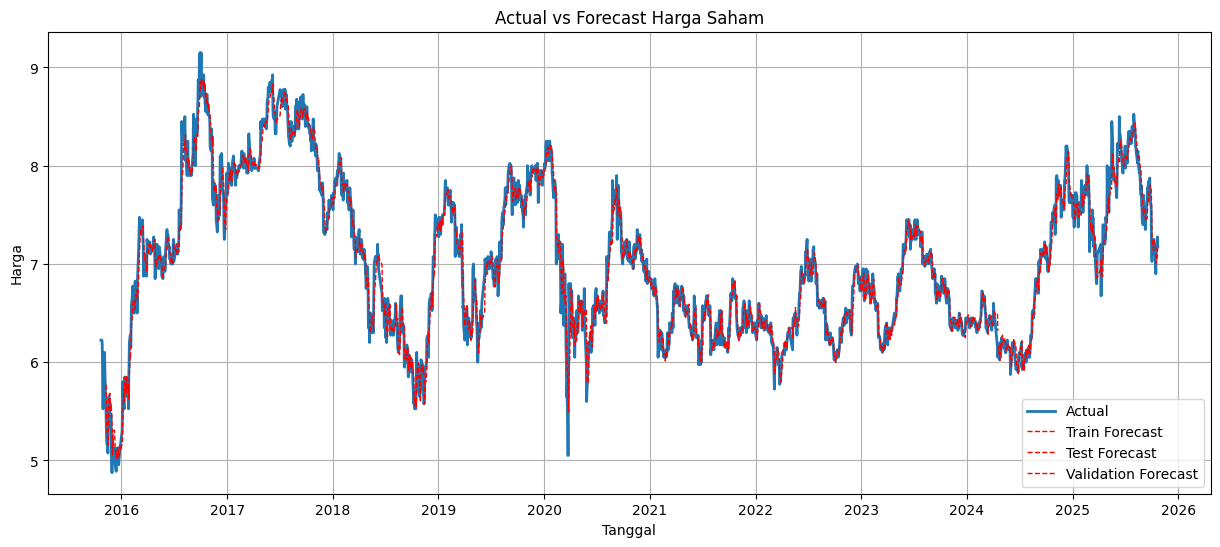

In [22]:
# ganti : grafik actual dan forecast aja (2 line only)
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

# Actual (DATA ASLI)
plt.plot(df['Tanggal'], df['Terakhir'], label='Actual', linewidth=2)

# Forecast
plt.plot(df['Tanggal'], train_plot, label='Train Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], test_plot, label='Test Forecast', color='red', linestyle='--', linewidth=1)
plt.plot(df['Tanggal'], val_plot, label='Validation Forecast', color='red', linestyle='--', linewidth=1)

plt.title("Actual vs Forecast Harga Saham")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [23]:
# pastikan ini sudah ada di awal (sekali saja cukup)
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df_plot = df.copy()

# WAJIB: sort berdasarkan tanggal
df_plot['Tanggal'] = pd.to_datetime(df_plot['Tanggal'])
df_plot = df_plot.sort_values(by='Tanggal').reset_index(drop=True)
df_plot['Forecast'] = np.nan

# masukin train
df_plot['Forecast'].iloc[sequence_length:best_train_size+sequence_length] = train_pred.flatten()

# masukin test
df_plot['Forecast'].iloc[test_start:test_start+len(test_pred)] = test_pred.flatten()

last_14 = df_plot.tail(30)

# next business day (biar gak kena weekend)
next_date = df['Tanggal'].iloc[-1] + pd.offsets.BDay(1)
next_value = pred_real[0][0]

/var/folders/wy/pyy9phgx4kngk0b6dmzdhvdh0000gn/T/ipykernel_2665/3021974255.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_plot['Forecast'].iloc[sequence_length:best_train_size+sequence_length] = train_pred.flatten()
/var/folders/wy/

In [34]:
print(y_pred_test_ori[:10])
print(y_test_ori[:10])

[[7.071946 ]
 [7.1106987]
 [7.1641064]
 [7.187721 ]
 [7.284656 ]
 [7.3362794]
 [7.368808 ]
 [7.4395103]
 [7.4714313]
 [7.494746 ]]
[[7.2  ]
 [7.175]
 [7.175]
 [7.425]
 [7.4  ]
 [7.425]
 [7.5  ]
 [7.525]
 [7.5  ]
 [7.525]]


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test_ori, y_pred_test_ori))
mae = mean_absolute_error(y_test_ori, y_pred_test_ori)
r2 = r2_score(y_test_ori, y_pred_test_ori)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 0.1878
MAE: 0.1482
R² Score: 0.7628


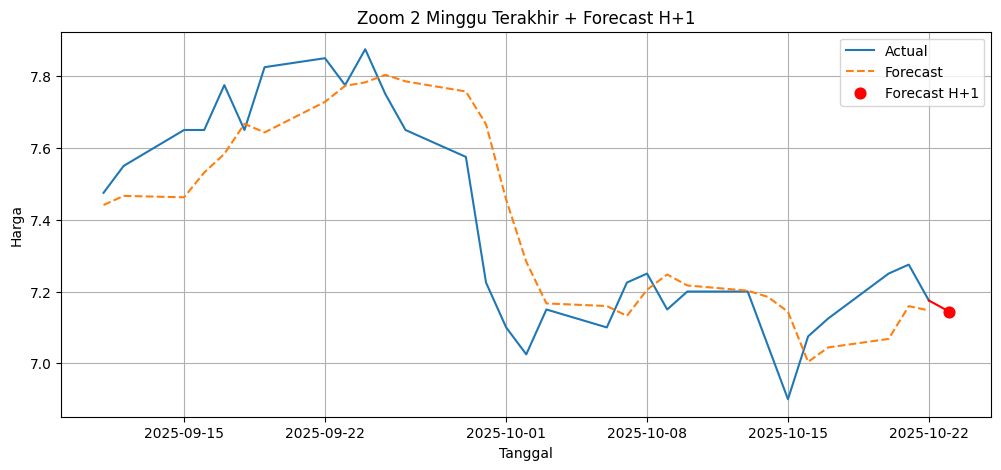

In [37]:
plt.figure(figsize=(12,5))

# actual
plt.plot(last_14['Tanggal'], last_14['Terakhir'], 
         label='Actual')

# forecast (overlap sama actual)
plt.plot(last_14['Tanggal'], last_14['Forecast'], 
         label='Forecast', linestyle='--')

# titik forecast H+1
plt.scatter(next_date, next_value, 
            color='red', label='Forecast H+1', s=60)

# garis bantu ke H+1
plt.plot([last_14['Tanggal'].iloc[-1], next_date],
         [last_14['Terakhir'].iloc[-1], next_value], color='red')

plt.title("Zoom 2 Minggu Terakhir + Forecast H+1")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.grid()

plt.show()

In [38]:
print("Forecast besok:", pred_real[0][0])

Forecast besok: 7.1443677


In [ ]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

best_model.save("model.keras")

import pickle
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
last_sequence = scaledDataMat[-sequence_length:]
last_sequence = last_sequence.reshape(1, sequence_length, 1)

import numpy as np
np.save("last_sequence.npy", last_sequence)

print("last_sequence berhasil disimpan!")

last_sequence berhasil disimpan!
